### Regression on Cleaned Data

Uses `resume_data_cleaned.csv` from the data cleaning notebook. Compares multiple approaches against the original baseline (TF-IDF on 4 raw columns, R²=0.477):

1. **Baseline replay** - TF-IDF on `combined_text` (same idea, but richer text from cleaning)
2. **Separate resume/job TF-IDF** - concatenate TF-IDF vectors from `resume_text` and `job_text` independently
3. **Structured features only** - just the engineered numeric features
4. **Hybrid** - TF-IDF + structured features together

In [1]:
# imports

import pandas as pd
import numpy as np
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [2]:
# load cleaned data

df = pd.read_csv('resume_data_cleaned.csv')
print(f"loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"columns: {list(df.columns)}")
print(f"\nnull counts:")
print(df.isnull().sum().to_string())

loaded: 9544 rows, 17 columns
columns: ['matched_score', 'resume_text', 'job_text', 'combined_text', 'num_skills', 'num_degrees', 'num_positions', 'experience_years', 'age_min', 'age_max', 'skill_jaccard', 'job_position_name', 'educational_requirements', 'skills_required', 'skills', 'degree_names', 'positions']

null counts:
matched_score                  0
resume_text                    0
job_text                       0
combined_text                  0
num_skills                     0
num_degrees                    0
num_positions                  0
experience_years            1364
age_min                     6133
age_max                     6133
skill_jaccard                  0
job_position_name              0
educational_requirements       0
skills_required             1701
skills                       112
degree_names                 112
positions                    140


In [3]:
# prepare data: fill text nulls, fill numeric nulls with median

# text columns should have no nulls, but guard against it
for col in ['resume_text', 'job_text', 'combined_text']:
    df[col] = df[col].fillna('')

# structured feature columns
struct_cols = ['num_skills', 'num_degrees', 'num_positions',
               'experience_years', 'age_min', 'age_max', 'skill_jaccard']

# fill numeric nulls with median
for col in struct_cols:
    df[col] = df[col].fillna(df[col].median())

y = df['matched_score'].values
print(f"target: {len(y)} values, mean={y.mean():.3f}, std={y.std():.3f}")

target: 9544 values, mean=0.661, std=0.167


In [4]:
# consistent train/test split for all experiments
train_idx, test_idx = train_test_split(
    np.arange(len(df)), test_size=0.2, random_state=42
)
y_train, y_test = y[train_idx], y[test_idx]
print(f"training samples: {len(train_idx)}")
print(f"test samples: {len(test_idx)}")

# store results for comparison
results = {}

training samples: 7635
test samples: 1909


### Experiment 1: TF-IDF on combined_text

Same approach as the original baseline but using the richer `combined_text` from cleaning (includes career_objective, skills, degrees, majors, positions, responsibilities, job_position_name, educational_requirements, experience_requirement, skills_required).

In [5]:
# experiment 1: tfidf on combined_text

vec_combined = TfidfVectorizer(max_features=500)
X_combined = vec_combined.fit_transform(df['combined_text'])

X_train_1, X_test_1 = X_combined[train_idx], X_combined[test_idx]

model_1 = LinearRegression()
model_1.fit(X_train_1, y_train)
y_pred_1 = model_1.predict(X_test_1)

mse_1 = mean_squared_error(y_test, y_pred_1)
r2_1 = r2_score(y_test, y_pred_1)
results['1. combined_text tfidf'] = {'MSE': mse_1, 'R2': r2_1}

print(f"experiment 1 - combined_text tfidf (500 features)")
print(f"MSE: {mse_1:.4f}")
print(f"R2:  {r2_1:.4f}")
print(f"(original baseline was R2=0.4770)")

experiment 1 - combined_text tfidf (500 features)
MSE: 0.0140
R2:  0.4938
(original baseline was R2=0.4770)


### Experiment 2: Separate resume/job TF-IDF

Build independent TF-IDF vectors for `resume_text` and `job_text`, then concatenate them. This preserves the two-sided structure instead of mixing everything into one bag of words.

In [6]:
# experiment 2: separate resume/job tfidf

vec_resume = TfidfVectorizer(max_features=250)
vec_job = TfidfVectorizer(max_features=250)

X_resume = vec_resume.fit_transform(df['resume_text'])
X_job = vec_job.fit_transform(df['job_text'])

# concatenate the two tfidf matrices (250 + 250 = 500 total features)
X_separate = hstack([X_resume, X_job])

X_train_2, X_test_2 = X_separate[train_idx], X_separate[test_idx]

model_2 = LinearRegression()
model_2.fit(X_train_2, y_train)
y_pred_2 = model_2.predict(X_test_2)

mse_2 = mean_squared_error(y_test, y_pred_2)
r2_2 = r2_score(y_test, y_pred_2)
results['2. separate tfidf'] = {'MSE': mse_2, 'R2': r2_2}

print(f"experiment 2 - separate resume/job tfidf (250+250 features)")
print(f"MSE: {mse_2:.4f}")
print(f"R2:  {r2_2:.4f}")

experiment 2 - separate resume/job tfidf (250+250 features)
MSE: 0.0144
R2:  0.4792


### Experiment 3: Structured features only

Use only the engineered numeric features (counts, experience years, age range, skill jaccard) without any text. Tests whether the structured features alone carry signal.

In [7]:
# experiment 3: structured features only

X_struct = df[struct_cols].values

X_train_3, X_test_3 = X_struct[train_idx], X_struct[test_idx]

model_3 = LinearRegression()
model_3.fit(X_train_3, y_train)
y_pred_3 = model_3.predict(X_test_3)

mse_3 = mean_squared_error(y_test, y_pred_3)
r2_3 = r2_score(y_test, y_pred_3)
results['3. structured only'] = {'MSE': mse_3, 'R2': r2_3}

print(f"experiment 3 - structured features only ({len(struct_cols)} features)")
print(f"MSE: {mse_3:.4f}")
print(f"R2:  {r2_3:.4f}")
print(f"\nfeature coefficients:")
for col, coef in zip(struct_cols, model_3.coef_):
    print(f"  {col}: {coef:.4f}")

experiment 3 - structured features only (7 features)
MSE: 0.0251
R2:  0.0939

feature coefficients:
  num_skills: 0.0004
  num_degrees: 0.0044
  num_positions: 0.0081
  experience_years: -0.0048
  age_min: -0.0068
  age_max: 0.0146
  skill_jaccard: 1.4037


### Experiment 4: Hybrid (TF-IDF + structured features)

Combine the combined_text TF-IDF with the structured numeric features. Tests whether the two feature types are complementary.

In [8]:
# experiment 4: hybrid (combined_text tfidf + structured features)

from scipy.sparse import csr_matrix

X_struct_sparse = csr_matrix(X_struct)
X_hybrid = hstack([X_combined, X_struct_sparse])

X_train_4, X_test_4 = X_hybrid[train_idx], X_hybrid[test_idx]

model_4 = LinearRegression()
model_4.fit(X_train_4, y_train)
y_pred_4 = model_4.predict(X_test_4)

mse_4 = mean_squared_error(y_test, y_pred_4)
r2_4 = r2_score(y_test, y_pred_4)
results['4. hybrid (tfidf+struct)'] = {'MSE': mse_4, 'R2': r2_4}

print(f"experiment 4 - hybrid tfidf + structured ({X_hybrid.shape[1]} features)")
print(f"MSE: {mse_4:.4f}")
print(f"R2:  {r2_4:.4f}")

experiment 4 - hybrid tfidf + structured (507 features)
MSE: 0.0131
R2:  0.5256


### Results Comparison

In [9]:
# results comparison table

results_df = pd.DataFrame(results).T
results_df.index.name = 'experiment'
results_df['R2_vs_baseline'] = results_df['R2'] - 0.4770

# add original baseline row for reference
results_df.loc['0. original baseline'] = {'MSE': 0.0147, 'R2': 0.4770, 'R2_vs_baseline': 0.0}
results_df = results_df.sort_index()

print(results_df.round(4).to_string())

                             MSE      R2  R2_vs_baseline
experiment                                              
0. original baseline      0.0147  0.4770          0.0000
1. combined_text tfidf    0.0140  0.4938          0.0168
2. separate tfidf         0.0144  0.4792          0.0022
3. structured only        0.0251  0.0939         -0.3831
4. hybrid (tfidf+struct)  0.0131  0.5256          0.0486


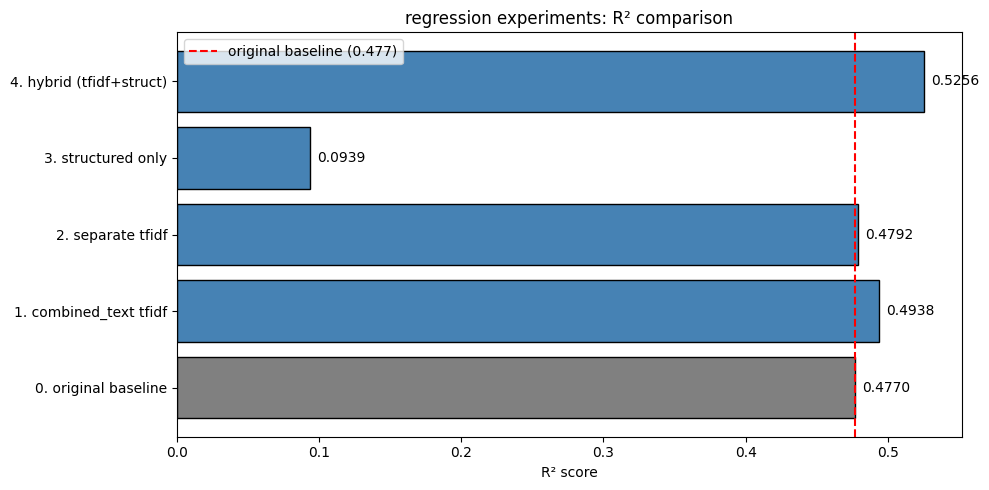

In [10]:
# bar chart comparing R2 scores

fig, ax = plt.subplots(figsize=(10, 5))

labels = list(results_df.index)
r2_vals = results_df['R2'].values
colors = ['gray'] + ['steelblue'] * (len(labels) - 1)

bars = ax.barh(labels, r2_vals, color=colors, edgecolor='black')
ax.axvline(x=0.4770, color='red', linestyle='--', label='original baseline (0.477)')
ax.set_xlabel('R² score')
ax.set_title('regression experiments: R² comparison')
ax.legend()

# annotate bars with values
for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

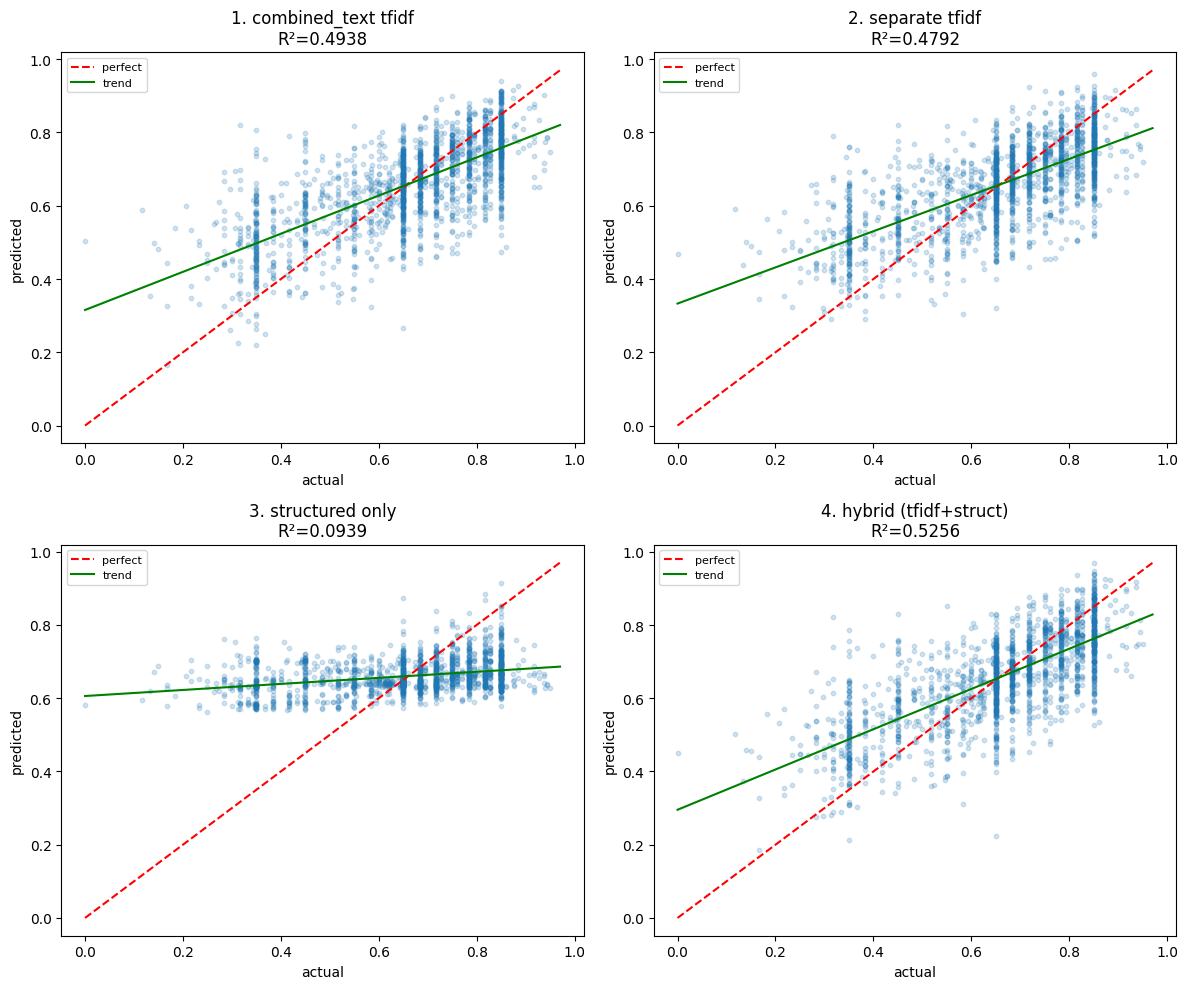

In [11]:
# visualize predictions vs actual for each experiment

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
experiments = [
    ('1. combined_text tfidf', y_pred_1),
    ('2. separate tfidf', y_pred_2),
    ('3. structured only', y_pred_3),
    ('4. hybrid (tfidf+struct)', y_pred_4),
]

for ax, (name, y_pred) in zip(axes.flat, experiments):
    ax.scatter(y_test, y_pred, alpha=0.2, s=10)
    ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='perfect')
    m, b = np.polyfit(y_test, y_pred, 1)
    ax.plot([y.min(), y.max()], [m * y.min() + b, m * y.max() + b], 'g-', label='trend')
    r2 = results[name]['R2']
    ax.set_title(f'{name}\nR²={r2:.4f}')
    ax.set_xlabel('actual')
    ax.set_ylabel('predicted')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Takeaways

- The original baseline used only 4 columns (skills, job_position_name, educational_requirements, responsibilities) mashed into one text blob. The cleaned `combined_text` includes more resume fields (career_objective, degrees, majors, positions), so any change in R² shows the impact of richer text.
- Separating resume-side and job-side TF-IDF gives the model a chance to weight the two sides independently, rather than treating all words as equal regardless of source.
- Structured features alone test whether counts and extracted numbers carry meaningful signal.
- The hybrid combines both signals. If it improves over TF-IDF alone, the structured features add complementary information.
- All experiments use the same train/test split (random_state=42) for fair comparison.
- Linear regression is still the bottleneck here. The next step is trying models that can capture non-linear relationships and semantic similarity (word2vec, transformers, siamese networks).